<h1 align="center" style="color: red;">Revision 1</h1>

In [184]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings("ignore")

<h1 align="center" style="color: blue;">Part 1: Load and Explore the Titanic Dataset</h1>

---


## Q1. Load & Inspect
1. Load the Titanic dataset using `sns.load_dataset('titanic')` and store it in a variable called `df` .
2. Print the **shape** of the dataset.
3. Display the **first 6 rows.**
4. Print the **column names.**

## ANSWER

In [185]:
# 1)
df = sns.load_dataset("titanic")

# 2)
print(df.shape)

# 3)
print(df.head(6))

# 4)
print(df.columns)

(891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   
5         0       3    male   NaN      0      0   8.4583        Q  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
5    man        True  NaN   Queenstown    no   True  
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'em

---

## Q2. Data Types & Missing Values
1. Use `.info()` to print column data types and non-null counts.
2. Print the **number of missing values per column** using `.isnull().sum()` .
3. Which column has the **most missing values**? Write your answer in a Markdown cell.

## ANSWER

In [186]:
# 1)
print(df.info())

# 2)
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None
survived         0
pclass           0
sex              0
age            17

### Q2.3.Answer:
> column **deck** has the most missing values

---

## Q3. Basic Statistics

1. Use `.describe()` to display summary statistics for numeric columns.
2. From the output, answer in a Markdown cell:
    - What is the **mean age** of passengers?
    - What is the **maximum fare** paid?
    - What percentage of passengers survived? (Hint: look at the `survived` mean, it represents the survival rate)

## ANSWER

In [187]:
# 1)
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Answer Q3.2

- Mean age of passengers is **29.7**
- Maximum fare paid is **512.3**
- **38.3%** of passengers survived

---

## Q4. Duplicates & Categorical Summary
1. Check how many **duplicate rows** exist in the dataset.
2. Use `.describe(include=['object', 'category'])` to get a summary of categorical columns.
3. From the output, answer in a Markdown cell:
    - What is the most common **sex** in the dataset and how many rows does it appear in?
    - What is the most common **embarkation port**?

## ANSWER

In [188]:
# 1)
print(df.duplicated().sum())

# 2)
print(df.describe(include=["object", "category"]))

107
         sex embarked  class  who deck  embark_town alive
count    891      889    891  891  203          889   891
unique     2        3      3    3    7            3     2
top     male        S  Third  man    C  Southampton    no
freq     577      644    491  537   59          644   549


### Answer Q4.3
- **male** is the most common sex and it appear in **577** rows
- **Southampton** is the most common embarkation port

---

<h1 align="center" style="color: blue;">Part 2: Data Cleaning</h1>

---

## Q5. Handle Missing Values
Create a new DataFrame called `df_clean` and apply the following cleaning steps **in order**:
1. **Drop** the `deck` column (too many missing values).
2. **Fill** missing values in the `age` column with the **median** age.
3. **Fill** missing values in the `embarked` column with the **mode** (most frequent value).
4. **Fill** missing values in the `embark_town` column with its **mode**.
5. After cleaning, print `.isnull().sum()` to confirm no missing values remain.

## ANSWER

In [189]:
# make a copy
df_clean = df

# Step 1: Drop deck
df_clean = df_clean.drop("deck", axis=1)

# Step 2: Fill age with median
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())

# Step 3: Fill embarked with mode
df_clean["embarked"] = df_clean["embarked"].fillna(df_clean["embarked"].mode()[0])

# Step 4: Fill embark_town with mode
df_clean["embark_town"] = df_clean["embark_town"].fillna(df_clean["embark_town"].mode()[0])

# Step 5: Confirm
df_clean.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

---

## Q6. Remove Duplicated & Redundant Columns
Continue working with `df_clean` :
1. Remove **duplicate rows** from `df_clean` using `drop_duplicates(inplace=True)` .
2. Drop the columns `'alive'` and `'embark_town'` - **REASON** - they are redundant (duplicated information from survived
and `embarked` ).
3. Print the **shape before and after** to show how many rows were removed.
4. Display the first 5 rows of the cleaned DataFrame.

## ANSWER

In [190]:
#3) print shape before
print(df_clean.shape)

# 1)
df_clean.drop_duplicates(inplace=True)

# 2)
df_clean.drop(['alive', 'embark_town'], axis=1, inplace=True)

# 3) print shape after
print(df_clean.shape)

# 4) display the first 5 rows
print(df_clean.head())

(891, 14)
(775, 12)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male  alone  
0    man        True  False  
1  woman       False  False  
2  woman       False   True  
3  woman       False  False  
4    man        True   True  


---

## Q7. Outlier Detection
1. Create a **boxplot** for the `fare` column to visually identify outliers.
2. Use the **IQR method** to calculate the upper bound for outliers:
    - `Q1 = fare.quantile(0.25)` , `Q3 = fare.quantile(0.75)`
    - `IQR = Q3 - Q1`
    - `upper_bound = Q3 + 1.5 * IQR`
3. Print how many rows have a fare above the upper bound.
4. Create a new column `fare_capped` that **clips** the fare at the upper bound using `.clip(upper=upper_bound)` .

## ANSWER

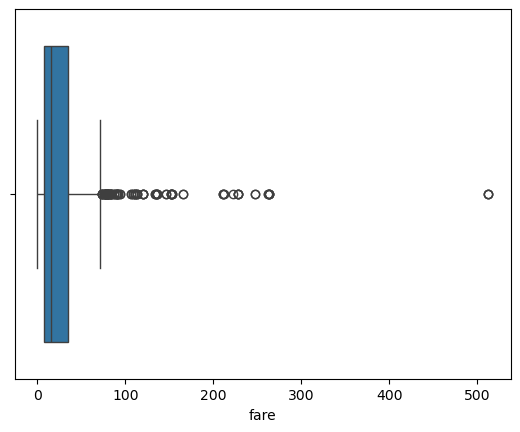

In [191]:
# Part 1: boxplot
plt.plot()
sns.boxplot(data=df_clean, x=df_clean["fare"])
plt.show()

In [192]:
# Part 2: IQR method
Q1 = df_clean["fare"].quantile(0.25)
Q3 = df_clean["fare"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

In [193]:
# Part 3: Count outliers
print("Fare count above upper bound:", df_clean[df_clean["fare"] > upper_bound]["fare"].count())

Fare count above upper bound: 102


In [194]:
# Part 4: Cap fares
df_clean["fare_capped"] = df_clean["fare"].clip(upper=upper_bound)

---

<h1 align="center" style="color: blue;">Part 3: Filtering, Sorting & Grouping</h1>

---

## Q8. Filtering
Using `df_clean` :
1. Filter passengers who **survived** ( `survived == 1` ) AND were in **First class** ( `class == 'First'` ). How many are there?
2. Filter passengers who were **older than 60**. Print how many there are and display their names if the column exists, otherwise
display the filtered DataFrame.
3. Filter passengers who paid a fare **above $50** and were **female**. How many rows match?

## ANSWER

In [195]:
# Part 1
df_clean[(df_clean.survived == 1) & (df_clean["class"] == 'First')]["survived"].count()

np.int64(133)

In [196]:
# Part 2
print(df_clean[df_clean.age > 60]["age"].count())
df_clean[df_clean.age > 60]

21


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone,fare_capped
33,0,2,male,66.0,0,0,10.5000,S,Second,man,True,True,10.50000
54,0,1,male,65.0,0,1,61.9792,C,First,man,True,False,61.97920
96,0,1,male,71.0,0,0,34.6542,C,First,man,True,True,34.65420
116,0,3,male,70.5,0,0,7.7500,Q,Third,man,True,True,7.75000
170,0,1,male,61.0,0,0,33.5000,S,First,man,True,True,33.50000
252,0,1,male,62.0,0,0,26.5500,S,First,man,True,True,26.55000
275,1,1,female,63.0,1,0,77.9583,S,First,woman,False,False,73.41975
280,0,3,male,65.0,0,0,7.7500,Q,Third,man,True,True,7.75000
326,0,3,male,61.0,0,0,6.2375,S,Third,man,True,True,6.23750
438,0,1,male,64.0,1,4,263.0000,S,First,man,True,False,73.41975


In [197]:
# Part 3
df_clean[(df_clean.fare > 50) & (df_clean.sex == "female")]["fare"].count()

np.int64(84)

---

## Q9. Sorting
Using `df_clean` :
1. Sort the DataFrame by `fare` in **descending order** and display the **top 5 rows** (only columns: `sex` , `age` , `class` , `fare` ,
`survived` ).
2. Sort by `age` in **ascending order** and display the **5 youngest passengers**.
3. In a Markdown cell, state one observation from each sorted result.

## ANSWER

In [198]:
# 1)
print(df_clean.sort_values("fare", ascending=False).head()[["sex", "age", "class", "fare", "survived"]])

# 2)
print(df_clean.sort_values("age", ascending=True).head()[["sex", "age", "class", "fare", "survived"]])

        sex   age  class      fare  survived
258  female  35.0  First  512.3292         1
737    male  35.0  First  512.3292         1
679    male  36.0  First  512.3292         1
88   female  23.0  First  263.0000         1
341  female  24.0  First  263.0000         1
        sex   age   class     fare  survived
803    male  0.42   Third   8.5167         1
755    male  0.67  Second  14.5000         1
469  female  0.75   Third  19.2583         1
831    male  0.83  Second  18.7500         1
78     male  0.83  Second  29.0000         1


**My observations:**
- All of them survived, all of them in the first class, their age between 23 - 36, fare > 263
- They all babies, all of them survived, all of them from Third and Second class

---

## Q10. GroupBy & Aggregation
Using df_clean :
1. Use `.groupby('sex')['survived'].mean()` to find the **survival rate by sex**. Round to 2 decimal places.
2. Use `.groupby('class')['survived'].mean()` to find the **survival rate by passenger class**.
3. Use `.groupby('class')['fare'].mean()` to find the **average fare per class**.
4. In a Markdown cell, write **two observations** from the results above.

## ANSWER

In [199]:
# 1)
print(df_clean.groupby("sex")["survived"].mean().round(2))

# 2)
print(df_clean.groupby("class")["survived"].mean())

# 3)
print(df_clean.groupby("class")["fare"].mean())

sex
female    0.74
male      0.22
Name: survived, dtype: float64
class
First     0.633333
Second    0.506098
Third     0.259352
Name: survived, dtype: float64
class
First     85.675199
Second    21.889279
Third     13.588850
Name: fare, dtype: float64


**My observations:**
1. The major percentage of **survived** passengers is **female** from **First** class
2. **The most fare** in the First class. **4-5 times more** than in **Second** and **Third*

---

<h1 align="center" style="color: blue;">Part 4: Visualization</h1>

---

## Q11. Histogram & Count Plot
Create a figure with **two subplots side by side** ( `figsize=(12, 4)` ):
- **Left subplot**: Histogram of `age` using `sns.histplot` with `kde=True` and `bins=20`. Title: `'Age Distribution'` .
- **Right subplot**: Count plot of `survived` using `sns.countplot` . Title: `'Survival Count'` .

Use `plt.tight_layout()` and `plt.show()` .

## ANSWER

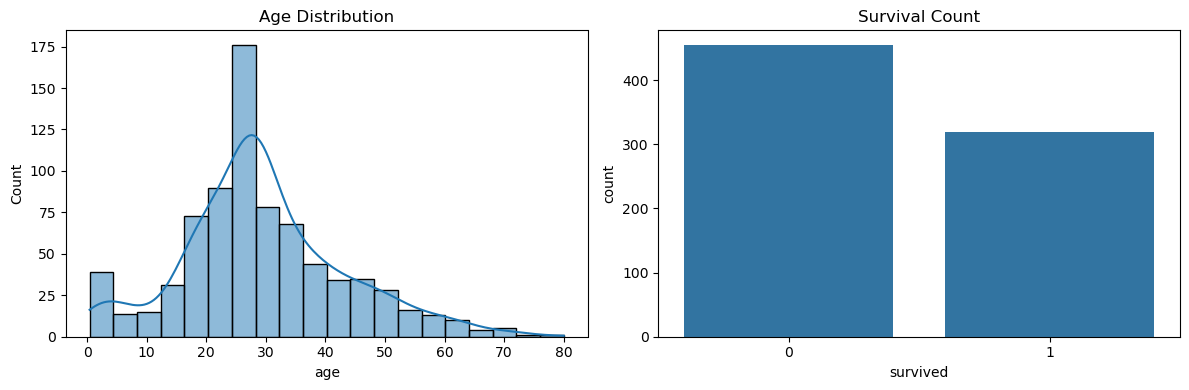

In [200]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(x=df_clean.age, kde=True, bins=20, ax=axes[0])
axes[0].set_title("Age Distribution")

sns.countplot(x=df_clean.survived, ax=axes[1])
axes[1].set_title("Survival Count")

plt.tight_layout()
plt.show()


---

## Q12. Categorical Plots
Create a figure with **two subplots side by side** ( `figsize=(12, 5)` ):
- **Left**: `sns.countplot` with `x='sex'` and `hue='survived'` . `Title: 'Survival by Sex'` .
- **Right**: `sns.countplot` with `x='class'` and `hue='survived'` . `Title: 'Survival by Class'` .

In a Markdown cell below, interpret each plot in **one sentence each**.

## ANSWER

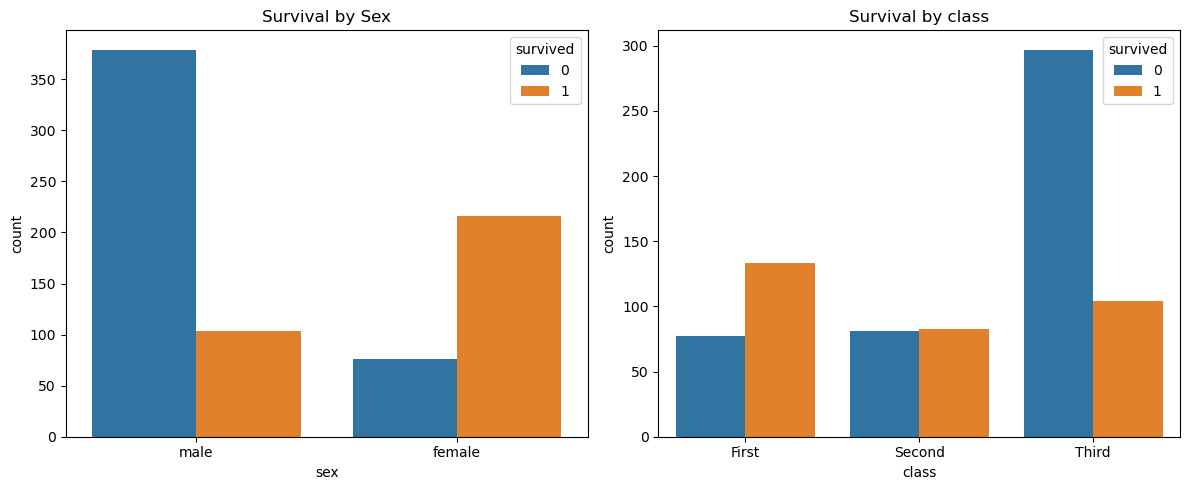

In [201]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=df_clean.sex, hue=df_clean.survived, ax=axes[0])
axes[0].set_title("Survival by Sex")

sns.countplot(x=df_clean["class"], hue=df_clean.survived, ax=axes[1])
axes[1].set_title("Survival by class")

plt.tight_layout()
plt.show()

**My interpretations:**
- More female passengers survived than male
- More passangers in the first class survived than in other classes

---

## Q13. Boxplot & Scatter Plot
1. Create a **boxplot** using `sns.boxplot(x='class', y='age', hue='survived', data=df_clean)` . Title: `'Age by Class and Survival'` .
2. Create a **scatter plot** using `sns.scatterplot(x='age', y='fare_capped', hue='survived', data=df_clean, alpha=0.6)` . Title: `'Age vs Fare (Capped) by Survival'` .
3. In a Markdown cell, write **one observation** from each plot.

## ANSWER

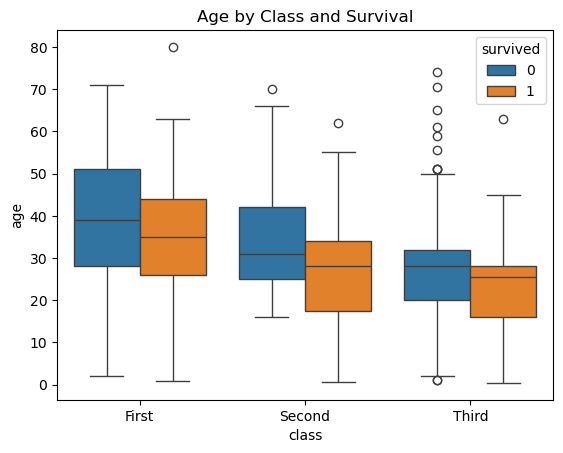

In [202]:
# Part 1. Boxplot
sns.boxplot(x='class', y='age', hue='survived', data=df_clean)
plt.title("Age by Class and Survival")
plt.show()

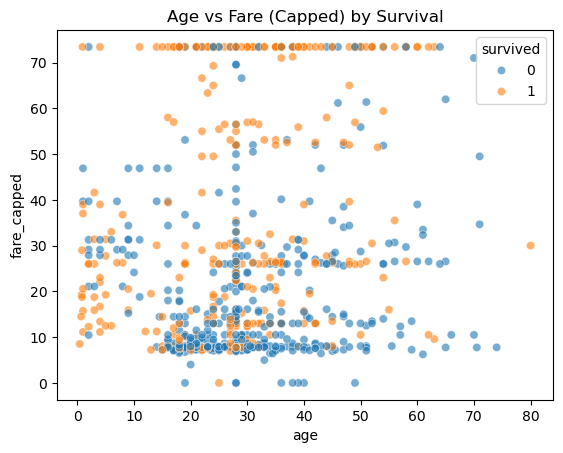

In [203]:
# Part 2. Scatter plot
sns.scatterplot(x='age', y='fare_capped', hue='survived', data=df_clean, alpha=0.6)
plt.title("Age vs Fare (Capped) by Survival")
plt.show()

**My observations:**
- In every class, young people is more likely to survive
- We can see that the more fare_capped is the more likely to passenger to survive

---

## Q14. Correlation Heatmap
1. Select all **numeric columns** from `df_clean` using `select_dtypes(include=np.number)` .
2. Compute the `correlation matrix` using `.corr()` .
3. Plot it as a **heatmap** using `sns.heatmap(... annot=True, cmap='coolwarm', center=0)` . Set `figsize=(8, 6)` . Title:`'Correlation Heatmap'` .
4. In a Markdown cell, identify the **two features most positively correlated with survival**.

## ANSWER

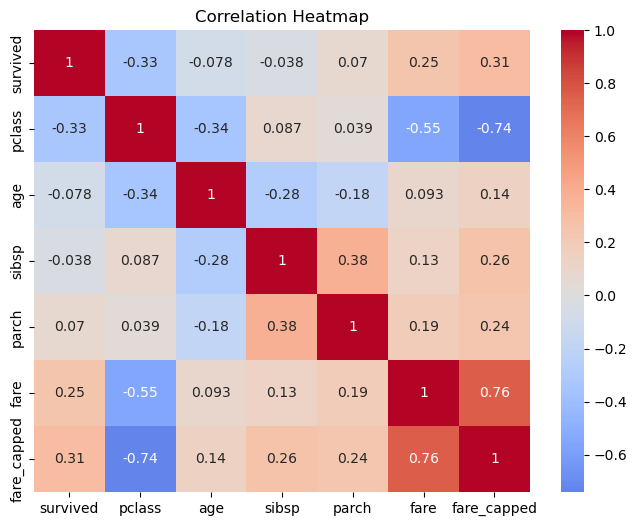

In [204]:
# 1)
numeric_columns = df_clean.select_dtypes(include=np.number)

# 2)
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_columns.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

### Answer 14.4:
- fare_capped
- pclass

---

<h1 align="center" style="color: blue;">Part 5: Tips Dataset: Filtering & Grouping</h1>

---

## Q15. Load and Filter the Tips Dataset
1. Load the **tips** dataset: `tips = sns.load_dataset('tips')` .
2. Display the first 5 rows and print the shape.
3. Filter only **dinner** orders where the `total bill is above $20`. How many rows match?
4. From those filtered rows, find the **average tip**.

## ANSWER

In [205]:
# 1)
tips = sns.load_dataset('tips')

# 2)
print(tips.head())

# 3)
print(tips[(tips.time == "Dinner") & (tips.total_bill > 20)].head())
print(tips[(tips.time == "Dinner") & (tips.total_bill > 20)]["tip"].count())

# 4)
print(tips[(tips.time == "Dinner") & (tips.total_bill > 20)]["tip"].mean())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
   total_bill   tip     sex smoker  day    time  size
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
5       25.29  4.71    Male     No  Sun  Dinner     4
7       26.88  3.12    Male     No  Sun  Dinner     4
81
3.8858024691358026


---

## Q16. Grouping the Tips Dataset

Using the full `tips` DataFrame:
1. Use `.groupby('day')['tip'].mean()` to find the **average tip by day**. Sort from highest to lowest.
2. Use `.groupby('smoker')['tip'].mean()` to compare tips between **smokers and non-smokers**.
3. In a Markdown cell, answer: **Do smokers tip more or less on average?**

## ANSWER

In [206]:
# 1)
print(tips.groupby("day")["tip"].mean().sort_values(ascending=False))

# 2)
print(tips.groupby("smoker")["tip"].mean())

day
Sun     3.255132
Sat     2.993103
Thur    2.771452
Fri     2.734737
Name: tip, dtype: float64
smoker
Yes    3.008710
No     2.991854
Name: tip, dtype: float64


### Answer 16.3:

- Yes, 0.017 more

---

## Q17. Visualize the Tips Dataset
Create a figure with **three subplots** ( `figsize=(15, 4)` ):
- **Left**: Scatter plot of `total_bill` vs `tip` (use `plt.scatter` ). Title: `'Tip vs Total Bill'` .
- **Center**: Bar plot of average tip by day (use `.plot(kind='bar')` on the grouped result). Title: `'Average Tip by Day'` .
- **Right**: Histogram of `tip` with `bins=15` and `edgecolor='k'` . Title: `'Tip Distribution'` .
  
Add axis labels and `plt.tight_layout()` .

## ANSWER


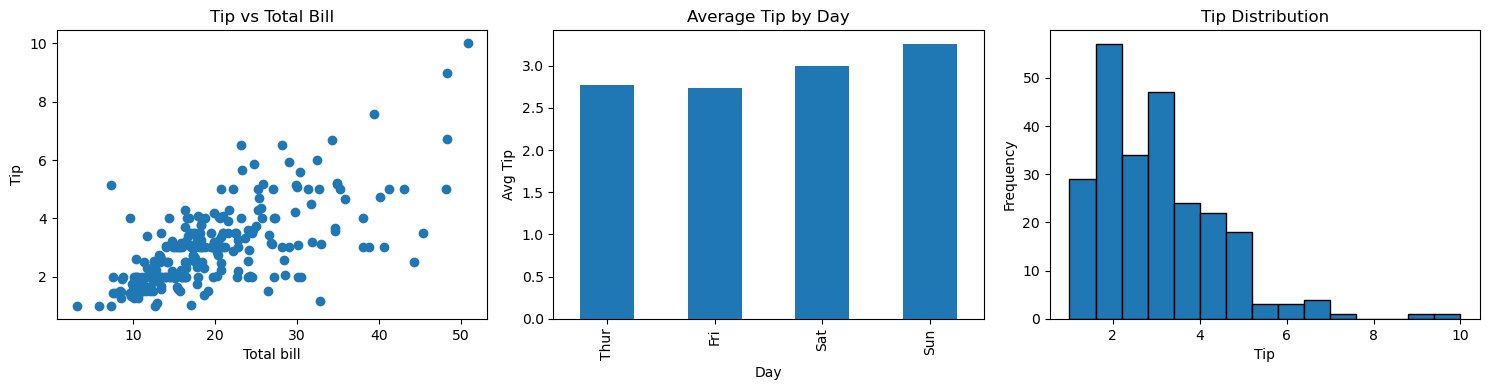

In [207]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(x=tips.total_bill, y=tips.tip)
axes[0].set_title("Tip vs Total Bill")
axes[0].set_xlabel("Total bill")
axes[0].set_ylabel("Tip")


avg_tip = tips.groupby("day")["tip"].mean()
avg_tip.plot(ax=axes[1], kind='bar')
axes[1].set_title("Average Tip by Day")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Avg Tip")

axes[2].hist(tips.tip, bins=15, edgecolor="k")
axes[2].set_title("Tip Distribution")
axes[2].set_xlabel('Tip')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

---

## Linear Regression on Tips
Using the `tips` dataset:
1. Extract `X` = `total_bill` (reshape to column: `tips[['total_bill']].values` ) and `y` = `tip` ( `tips[['tip']].values` ).
2. Train a `LinearRegression` model from `sklearn.linear_model` .
3. Print the **coefficient** and **intercept**. Interpret them in a sentence: "For every extra 1 dollar on the bill, the tip increases by..."
4. Plot the data as a scatter plot and overlay the **regression line** in red.
5. Predict the tip for a total bill of **$30**.

## ANSWER

In [208]:
X = tips[["total_bill"]].values
y = tips[["tip"]].values

In [209]:
# 2) train model
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [210]:
# 3) coefficient and intercept
print("coefficient:", model.coef_[0][0])
print("intercept:", model.intercept_[0])
print("For every extra 1 dollar on the bill, the tip increases by", model.coef_[0][0])

coefficient: 0.10502451738435337
intercept: 0.9202696135546731
For every extra 1 dollar on the bill, the tip increases by 0.10502451738435337


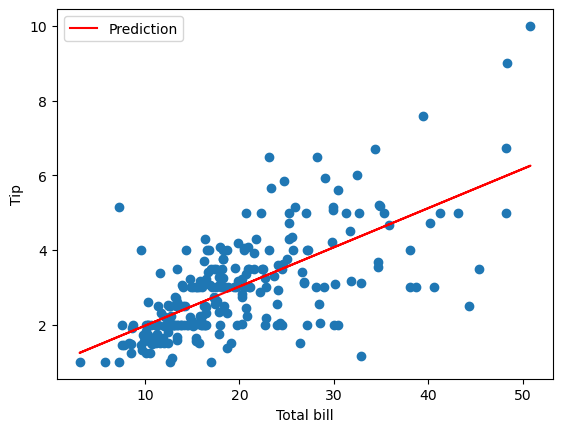

In [211]:
# 4) scatter + regression line
plt.figure()
plt.scatter(X, y)
plt.plot(X, model.predict(X), color="red", label="Prediction")
plt.xlabel("Total bill")
plt.ylabel("Tip")
plt.legend()
plt.show()

In [212]:
# 5) predict for $30
predicted = model.predict([[30]])
print("Predicted tip for 30$ bill:", predicted[0][0])

Predicted tip for 30$ bill: 4.071005135085274
